# Explainability: Isolation Forest

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import joblib
import plotly.express as px
from sklearn.decomposition import PCA
import shap


/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
isof = joblib.load('../models/isolation_forest_model.joblib')
test = pd.read_csv('../data/processed/if_test.csv')
train = pd.read_csv('../data/processed/if_train.csv')

Xtrain = train.drop('is_attack',axis=1)
ytrain = train['is_attack']

Xtest = test.drop('is_attack',axis=1)
ytest = test['is_attack']

In [3]:
scaler = isof.named_steps['scaler']
isolation_forest = isof.named_steps['if']

X_train_scaled = pd.DataFrame(
    scaler.transform(Xtrain), 
    columns=Xtrain.columns, 
    index=Xtrain.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(Xtest), 
    columns=Xtest.columns, 
    index=Xtest.index
)

train_anomaly_scores = -isolation_forest.score_samples(X_train_scaled)
test_anomaly_scores = -isolation_forest.score_samples(X_test_scaled)


/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


## Interpretacion global

In [4]:
explainer = shap.TreeExplainer(isolation_forest)

shap_values = explainer.shap_values(X_test_scaled)

shap_values_inverted = -shap_values

feature_importance = np.mean(np.abs(shap_values_inverted), axis=0)
feature_names = X_test_scaled.columns
top_10_indices = np.argsort(feature_importance)[-10:][::-1]  # descendente

# 4. Filtrar datos a top 10
X_top10 = X_test_scaled.iloc[:, top_10_indices]
shap_top10 = shap_values_inverted[:, top_10_indices]

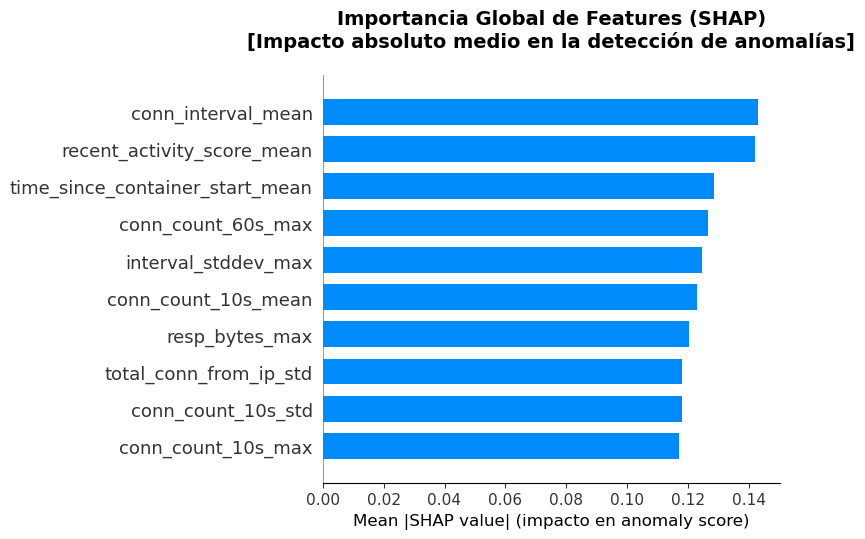

In [5]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_top10, X_top10, plot_type="bar", show=False)
plt.title("Importancia Global de Features (SHAP)\n[Impacto absoluto medio en la detección de anomalías]", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Mean |SHAP value| (impacto en anomaly score)", fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/shap_global_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()


- The previous plot shows the 10 most important variables for the model to detect anomalies.
- In the top, we can see **duration_zscore_mean**, **total_comm_from_ip**, **conn_count_10s_max**, **recent_activity_score_mean**, **resp_bytes_max**. There are also some other important features that are related to the intensity of connections and docker events.
- These visualizations do not show if the features are impacting to increase the anomaly score or reduce it. This will be visible in the next visualization.

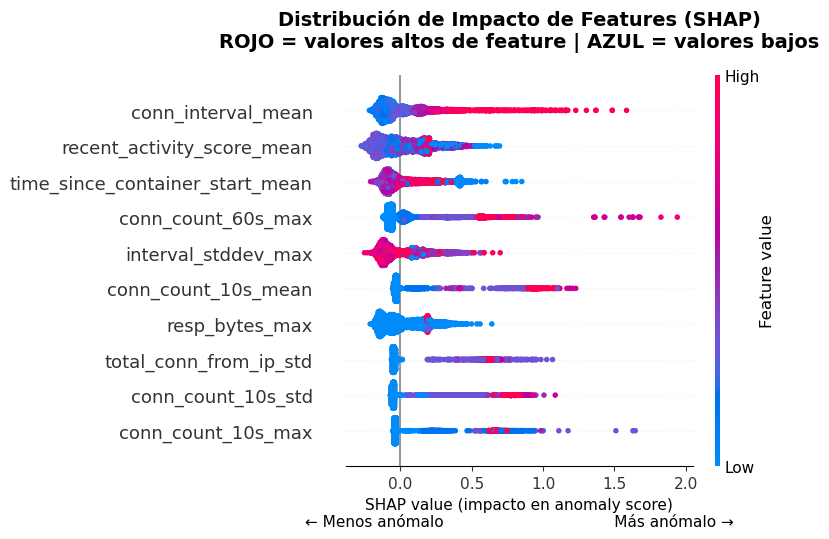

In [6]:
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_top10, X_top10, show=False)
plt.title("Distribución de Impacto de Features (SHAP)\n" + 
          "ROJO = valores altos de feature | AZUL = valores bajos", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP value (impacto en anomaly score)\n← Menos anómalo                                   Más anómalo →", 
           fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/shap_global_summary.png', dpi=300, bbox_inches='tight')
plt.show()

Here we get a better granularity of the importance of each top feature
- **duration_zscore_mean** represents the deviations/variability of the durations of the connections from the same IP address. `mean` represents the means of **duration_zscore** within a window. The higher this number, the higher is the difference between the durations of the connections from the same IP. This visualization shows that low **duration_zscore** makes the model think that the samples are more anomalous. This makes sense as the duration of the connections of the legitimate services are every variable. This connections are in keep-alive mode and they may end when the services shutdown which is a random event. In th eother hand, this pattern is consistent with automated or scripted attacks, where connections tend to have highly regular and controlled lifetimes (short-lived request-response interactions)
- **total_conn_from_ip_mean** will be analyzed in the next visualization as no pattern is visible in this one.
- **conn_count_10s_max** shows that more connections tend to be related to anomalies by the model. This is self-explainatory as the normal traffic has 1 connection and service restarts, selfregisters and attack have more connections.
- **recent_activity_score_mean** shows that a lower value is related to anomalous event as restarts or attacks. This feature measures the events made by that IP in the last 5 minutes. Anomalies act spontaniously whereas normal traffic act periodically (asking for a service IP and healthcheck)
- **resp_bytes_max** show that higher values are related to more anomalous samples. Attacks have an initial phase where they fetch many endpoints and make higher payloads' requests. Attacks will make GET https://consul_ip/v1/catalog/services (payload: every registered service) whereas legitimate services will make GET https://consul_ip/v1/catalog/service/order (payload: single service)
- **recent_docker_event** is a feature that tells if there has been a recent docker event. Its std shows if there has a change in this parameter during a window. Normal traffic are alined to docker events, it happens during container lifetime. Whereas, attacks can happen at any moment, been unaligned to docker events.
- the rest of features are variations of the mentioned ones.

<Figure size 1600x600 with 0 Axes>

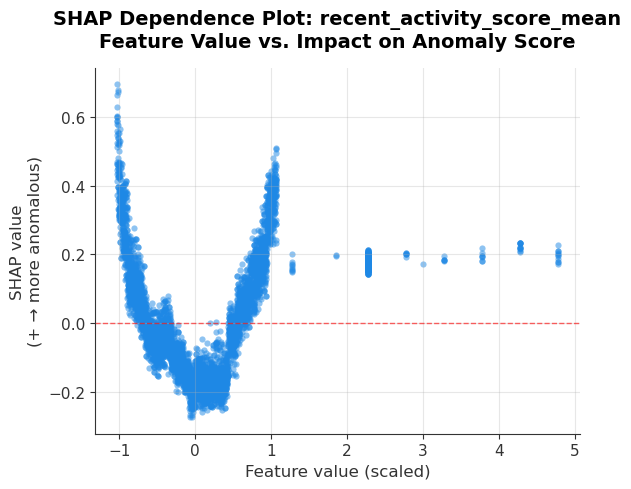

<Figure size 1600x600 with 0 Axes>

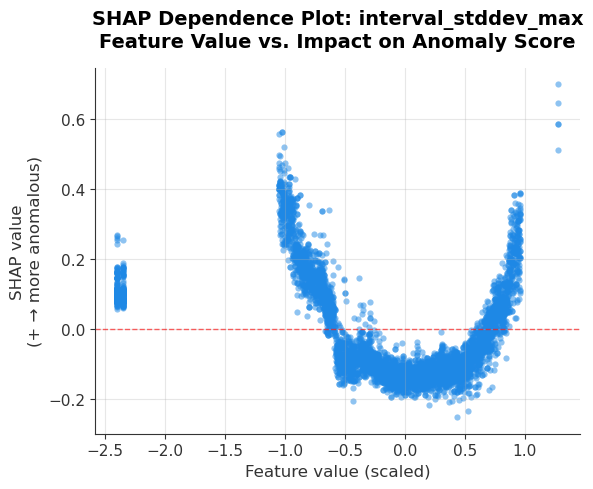

<Figure size 1600x600 with 0 Axes>

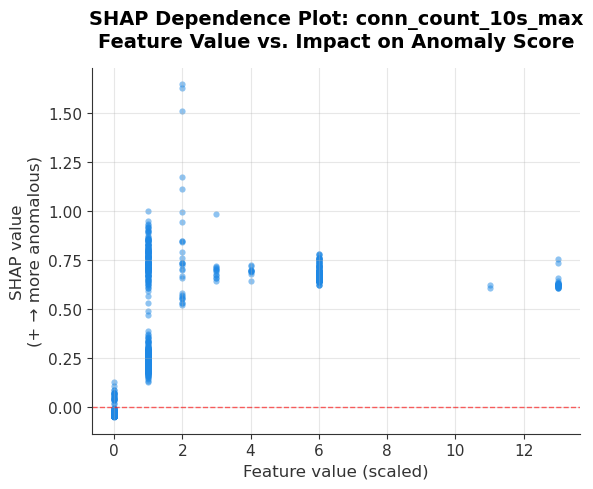

<Figure size 1600x600 with 0 Axes>

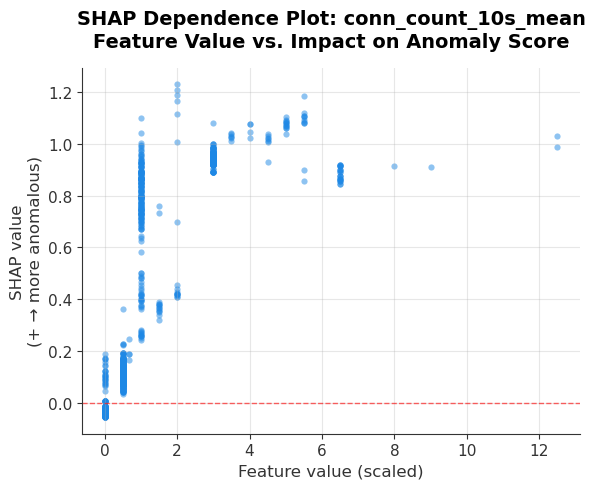

<Figure size 1600x600 with 0 Axes>

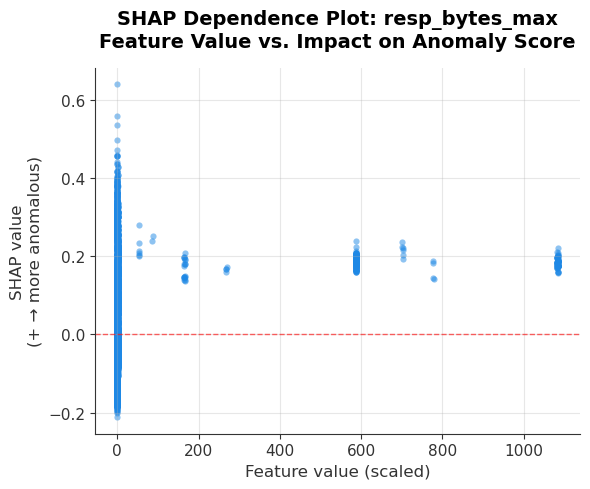

<Figure size 1600x600 with 0 Axes>

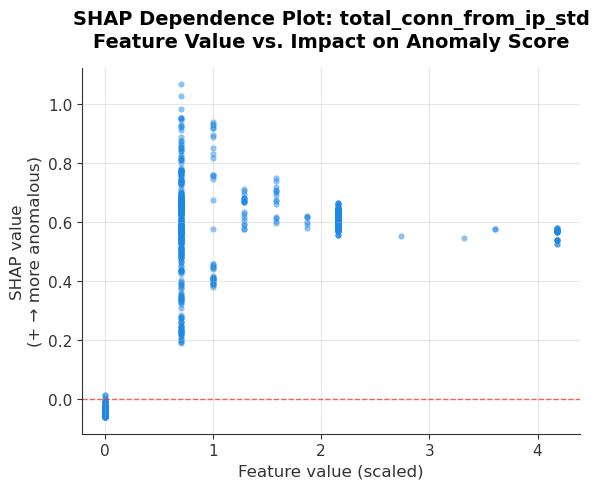

In [13]:
import matplotlib.pyplot as plt

# Lista de features a visualizar
features = [
    'recent_activity_score_mean', 
    'interval_stddev_max', 
    'conn_count_10s_max', 
    'conn_count_10s_mean', 
    'resp_bytes_max', 
    'total_conn_from_ip_std'
]

# Generar gráfico individual para cada feature
for feature in features:
    feature_idx = Xtest.columns.get_loc(feature)
    
    # Crear figura individual
    plt.figure(figsize=(16, 6))
    
    # Generar dependence plot
    shap.dependence_plot(
        feature_idx,
        shap_values_inverted,
        X_test_scaled,
        interaction_index=None,
        show=False,
        alpha=0.5,
        dot_size=20
    )
    
    # Personalizar
    plt.title(f'SHAP Dependence Plot: {feature}\n'
              'Feature Value vs. Impact on Anomaly Score',
              fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('SHAP value\n(+ → more anomalous)', fontsize=12)
    plt.xlabel('Feature value (scaled)', fontsize=12)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.6)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Guardar con nombre específico para cada feature
    filename = feature.lower().replace('_', '-')
    plt.savefig(f'../reports/figures/shap_dependence_{filename}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()  # Cerrar figura para liberar memoria

In [8]:
import matplotlib.pyplot as plt

# Nombre de la feature
feature = ['recent_activity_score_std', 'conn_count_10s_max']
feature_idx = Xtest.columns.get_loc(feature)

# Crear figura individual
plt.figure(figsize=(16, 6))

# Generar dependence plot (sin interacción automática)
shap.dependence_plot(
    feature_idx,
    shap_values_inverted,
    X_test_scaled,
    interaction_index=None,  # desactiva coloreado por otra feature
    show=False,
    alpha=0.5,
    dot_size=20
)

# Personalizar
plt.title(f'SHAP Dependence Plot: {feature}\n'
          'Feature Value vs. Impact on Anomaly Score',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('SHAP value\n(+ → more anomalous)', fontsize=12)
plt.xlabel('Feature value (scaled)', fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.6)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Guardar
plt.savefig('../reports/figures/shap_dependence_total_conn_from_ip_mean.png', 
            dpi=300, bbox_inches='tight')
plt.show()

InvalidIndexError: ['recent_activity_score_std', 'conn_count_10s_max']

- Zooming in **total_conn_from_ip_mean**, a clear U pattern is visible. The extreme values are clearly related to high **anomaly_score**. The model shows that new IPs with few connections and IPs with many connections are anomalous. 

From the knowledge acquired during the creating phase of the dataset and the Exploratory Data analsys, some hipothesis where made:
- **n_connections** is very predictive and should be related to connection count type of features like **conn_count_10s_max** 
- **burst_score_mean** should be highly related to attack patterns as attackers fetch many endpoints in short periods. Normal:0.0050 ; Attacks:0.8440
- **ja3_frequency** is the feature that shows how many times a same TLS handshake has been seen. During the clustering phase of modeling with GMM this was seen:

    
    Feature                C0 (Legit)  C1_Legit  C1_Attack 

    ja3_frequency_mean     68.1104     68.7149   392.5147

Theoretically this feature should be related to high **conn_count_10s_max** as many connection should mean TLS handshake seen many times.

Let's visualize these features in dependance plots.

<Figure size 1600x600 with 0 Axes>

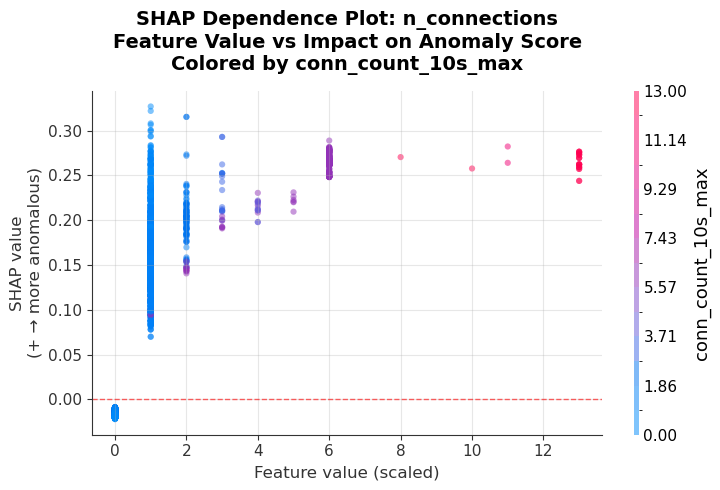

<Figure size 1600x600 with 0 Axes>

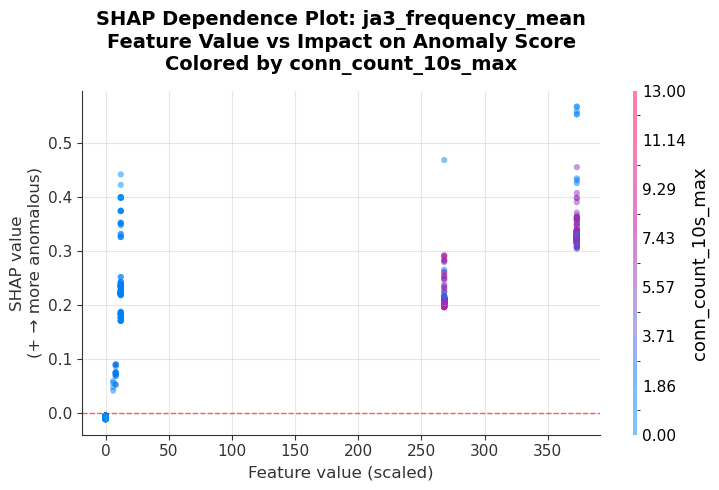

<Figure size 1600x600 with 0 Axes>

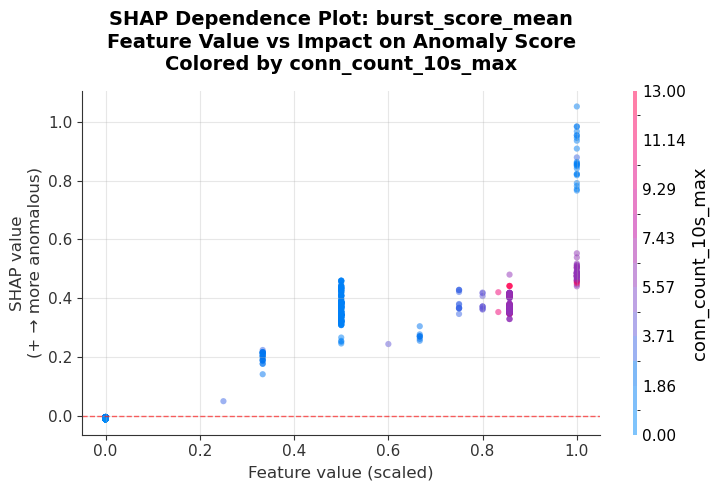

In [ ]:
import matplotlib.pyplot as plt
import shap

features_to_plot = [
    'n_connections',
    'ja3_frequency_mean',
    'burst_score_mean'
]

interaction_feature = 'conn_count_10s_max'
interaction_idx = X.columns.get_loc(interaction_feature)

for feature in features_to_plot:
    feature_idx = X.columns.get_loc(feature)

    plt.figure(figsize=(16, 6))

    shap.dependence_plot(
        feature_idx,
        shap_values_inverted,
        X_scaled_df,
        interaction_index=interaction_idx,
        show=False,
        alpha=0.5,
        dot_size=20
    )

    plt.title(
        f'SHAP Dependence Plot: {feature}\n'
        f'Feature Value vs Impact on Anomaly Score\n'
        f'Colored by {interaction_feature}',
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    plt.xlabel('Feature value (scaled)', fontsize=12)
    plt.ylabel('SHAP value\n(+ → more anomalous)', fontsize=12)

    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.6)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        f'../reports/figures/shap_dependence_{feature}_colored_by_{interaction_feature}.png',
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


- Making a zoom in the **total_conn_from_ip_mean** feature, it is visible that both high and low values make the model think that the sample si more anomalous. In other words, both new ips and ips with many connections are susceptible of been anomalies.
- Contrarely to what has been said before, **recent_activity_score_mean** is not as clear as we thought. We can feel that lower values are related to more anomalous samples but the U pattern is not able to separate clearly high and low values.

### Model Specific: Average path length

In Isolation Forest, the path length represents the number of splits required to isolate a data point in the decision trees.
Shorter path lengths indicate that a sample is easier to isolate and therefore more likely to be anomalous, while longer paths suggest normal behavior.

It is interesting to see how the model is splitting the data.

/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreeRegressor was fitted

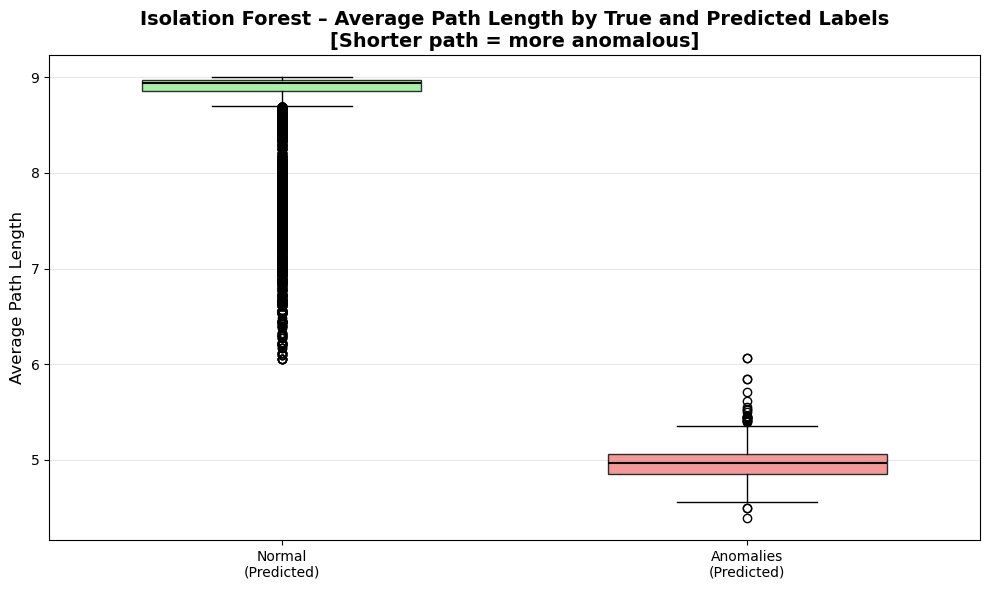

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Asumimos que ya tienes:
# - isolation_forest: modelo entrenado (IsolationForest)
# - X_scaled_df: datos escalados (DataFrame o array)
# - y: etiquetas reales (0 = normal, 1 = attack)
# - predictions: predicciones del modelo (-1 = anomaly, 1 = normal)

# ==============================================================================
# 1. Calcular average path length
# ==============================================================================
n_estimators = len(isolation_forest.estimators_)
path_lengths = np.zeros((len(X_scaled_df), n_estimators))

for tree_idx, estimator in enumerate(isolation_forest.estimators_):
    paths = estimator.decision_path(X_scaled_df)
    path_lengths[:, tree_idx] = np.asarray(paths.sum(axis=1)).flatten()

avg_path_lengths = path_lengths.mean(axis=1)

# ==============================================================================
# 2. Separar por clase real y predicha
# ==============================================================================
path_detected_normal = avg_path_lengths[predictions == 1]      # Predicted normal
path_detected_anomalies = avg_path_lengths[predictions == -1]  # Predicted anomaly

# ==============================================================================
# 3. Boxplot único
# ==============================================================================
plt.figure(figsize=(10, 6))

box_data = [
    path_detected_normal,
    path_detected_anomalies
]

box_labels = [
    'Normal\n(Predicted)',
    'Anomalies\n(Predicted)'
]

colors = ['lightgreen', 'lightcoral', 'palegreen', 'salmon']

bp = plt.boxplot(
    box_data,
    labels=box_labels,
    patch_artist=True,
    widths=0.6,
    medianprops=dict(color='black', linewidth=1.5)
)

# Aplicar colores
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

plt.ylabel('Average Path Length', fontsize=12)
plt.title('Isolation Forest – Average Path Length by True and Predicted Labels\n'
          '[Shorter path = more anomalous]', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/isoforest_path_length_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

To understand the guts of isolation Forest, it is visible that the path length is much lower for the anomalies (5 median) than for the normal traffic (9 median).

## Interpretacion local


📊 Generating: Most Anomalous (index 122)


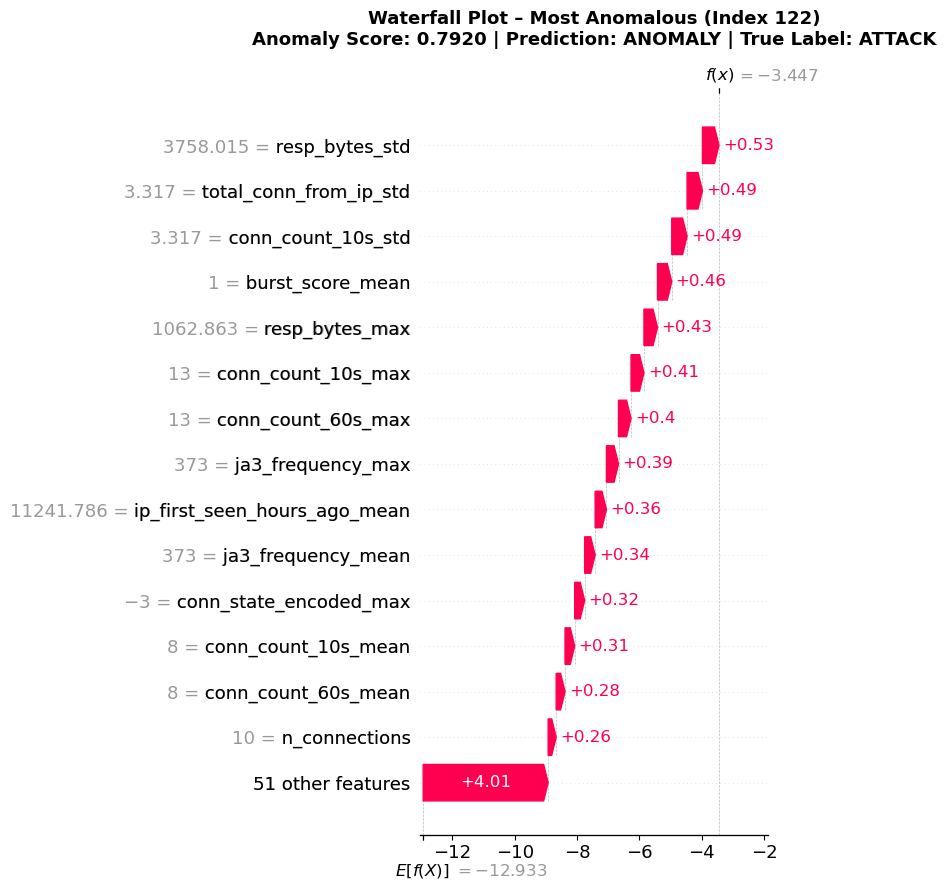


📊 Generating: Least Anomalous (index 4921)


/var/folders/vq/wvck34h52895nn992tsbrx640000gn/T/ipykernel_7220/3052752062.py:47: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vq/wvck34h52895nn992tsbrx640000gn/T/ipykernel_7220/3052752062.py:49: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300, bbox_inches='tight')
/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


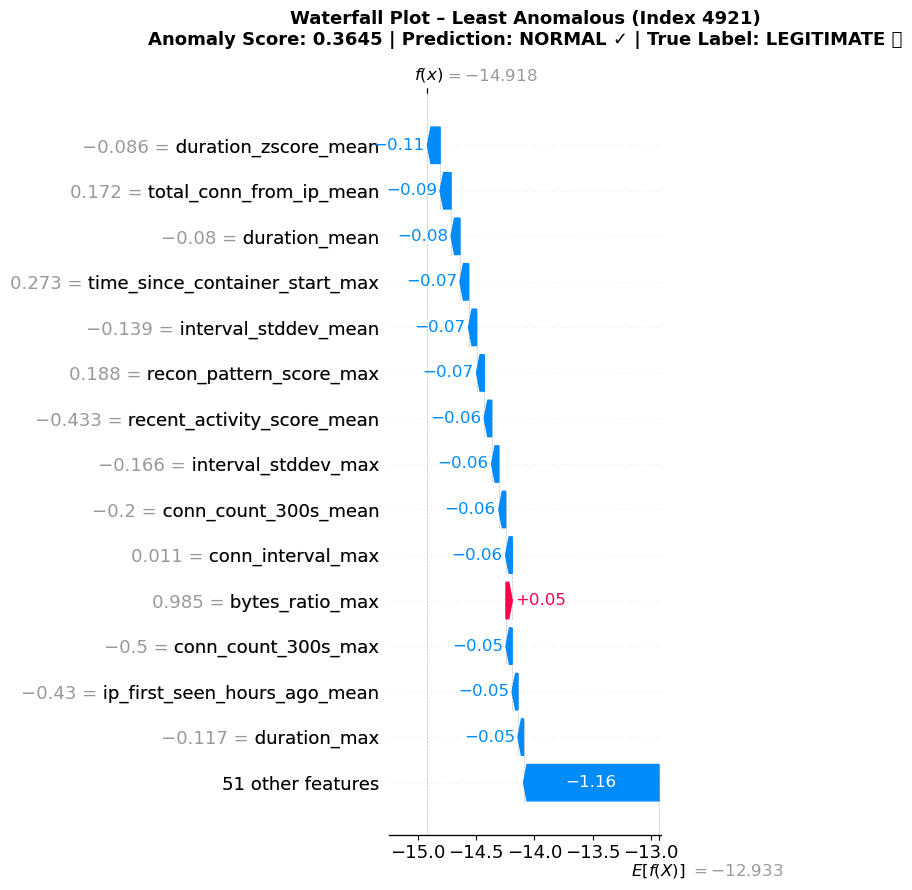

/var/folders/vq/wvck34h52895nn992tsbrx640000gn/T/ipykernel_7220/3052752062.py:47: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vq/wvck34h52895nn992tsbrx640000gn/T/ipykernel_7220/3052752062.py:49: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=300, bbox_inches='tight')



📊 Generating: Closest to Score=0.55 (index 7362)


/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


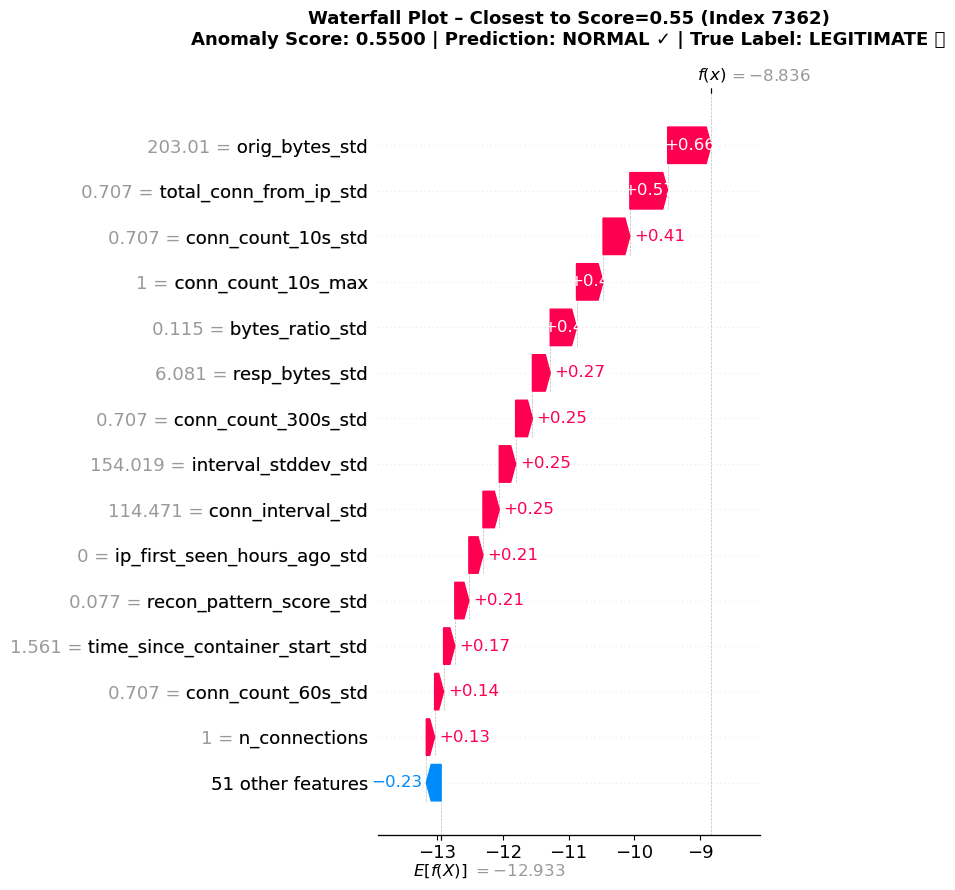

In [ ]:
# Most anomalous
most_anomalous_idx = np.argmax(anomaly_scores)

# Least anomalous (most normal)
least_anomalous_idx = np.argmin(anomaly_scores)

# Instance closest to anomaly_score = 0.55
target_score = 0.55
closest_to_055_idx = np.argmin(np.abs(anomaly_scores - target_score))

instances = {
    "Most Anomalous": most_anomalous_idx,
    "Least Anomalous": least_anomalous_idx,
    "Closest to Score=0.55": closest_to_055_idx
}

# =============================================================================
# 2. Función para generar waterfall plot + tabla explicativa
# =============================================================================

def plot_waterfall_and_explain(instance_name, idx):
    print(f"\n📊 Generating: {instance_name} (index {idx})")
    
    # Create SHAP Explanation object
    explanation = shap.Explanation(
        values=shap_values_inverted[idx],
        base_values=-explainer.expected_value,  # inverted to match anomaly_score = -score
        data=X_scaled_df.iloc[idx],
        feature_names=X.columns.tolist()
    )
    
    # Plot
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(explanation, max_display=15, show=False)
    
    real_label = "ATTACK" if y.iloc[idx] == 1 else "LEGITIMATE 🟢"
    pred_label = "ANOMALY" if predictions[idx] == -1 else "NORMAL ✓"
    
    plt.title(
        f"Waterfall Plot – {instance_name} (Index {idx})\n"
        f"Anomaly Score: {anomaly_scores[idx]:.4f} | "
        f"Prediction: {pred_label} | "
        f"True Label: {real_label}",
        fontsize=13, fontweight='bold', pad=15
    )
    
    plt.tight_layout()
    filename = f"../reports/figures/shap_waterfall_{instance_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()    
    # Detailed explanation table
    instance_shap_df = pd.DataFrame({
        'feature': X.columns,
        'value_original': X.iloc[idx].values,
        'value_scaled': X_scaled_df.iloc[idx].values,
        'shap_value': shap_values_inverted[idx],
        'abs_shap': np.abs(shap_values_inverted[idx])
    }).sort_values('abs_shap', ascending=False)

# =============================================================================
# 3. Generar los tres gráficos
# =============================================================================

for name, idx in instances.items():
    plot_waterfall_and_explain(name, idx)